# 📊 Unemployment Analysis in India

## Oasis Infobyte Internship – Data Science Track

### Objective

The objective of this project is to analyze unemployment trends across different states in India using exploratory data analysis (EDA). The analysis focuses on regional differences, monthly trends, and the impact of the COVID-19 pandemic on unemployment rates.

This project demonstrates data cleaning, visualization, statistical analysis, and business insight generation using Python.

# Table of Contents

1. Import Libraries
2. Load Dataset
3. Data Cleaning
4. Dataset Information
5. Exploratory Data Analysis
   - Region-wise Analysis
   - Monthly Trend
   - Time-Series Analysis
   - Top 10 States
   - Correlation Heatmap
   - Pre vs Post COVID
6. Conclusion

# 1. Import Libraries

In this section, we import all the Python libraries required for data manipulation, visualization, and analysis.

In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Make plots look better
plt.style.use("ggplot")

# 2. Load the Dataset

The unemployment dataset is loaded into a Pandas DataFrame for analysis.

In [27]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gokulrajkmv/unemployment-in-india")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'unemployment-in-india' dataset.
Path to dataset files: /kaggle/input/unemployment-in-india


In [28]:
import os

print(os.listdir(path))

['Unemployment_Rate_upto_11_2020.csv', 'Unemployment in India.csv']


In [29]:
import pandas as pd
import os

file_path = os.path.join(path, "Unemployment in India.csv")

df = pd.read_csv(file_path)

# 3&4. Data Inspection

Before performing any analysis, we inspect the dataset to understand its structure, dimensions, data types, and identify potential data quality issues.

In [30]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [31]:
df.shape

(768, 7)

In [32]:
df.info()
# Date   740 non-null  object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [34]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [33]:
df[df.isnull().any(axis=1)]

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,NaN,NaN,NaN,NaN,NaN,NaN,NaN
364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
368,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
df = df.dropna()

In [36]:
df.shape

(740, 7)

In [37]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [38]:
# Display unique values for all object columns

for col in df.select_dtypes(include="object").columns:
    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(f"{'='*50}")
    print(df[col].unique())


Column: Region
['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'Chandigarh']

Column:  Date
[' 31-05-2019' ' 30-06-2019' ' 31-07-2019' ' 31-08-2019' ' 30-09-2019'
 ' 31-10-2019' ' 30-11-2019' ' 31-12-2019' ' 31-01-2020' ' 29-02-2020'
 ' 31-03-2020' ' 30-04-2020' ' 31-05-2020' ' 30-06-2020']

Column:  Frequency
[' Monthly' 'Monthly']

Column: Area
['Rural' 'Urban']


In [39]:
object_columns = df.select_dtypes(include="object").columns

for col in object_columns:
    df[col] = df[col].str.strip()

In [45]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [46]:
df.columns = df.columns.str.strip()
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [47]:
df["Frequency"].value_counts()

,count
Frequency,
Monthly,740


In [20]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(df[col].value_counts())


Column: Region
Region
Andhra Pradesh      28
Bihar               28
Chhattisgarh        28
Delhi               28
Karnataka           28
Gujarat             28
Haryana             28
Himachal Pradesh    28
Jharkhand           28
Maharashtra         28
Madhya Pradesh      28
Kerala              28
West Bengal         28
Uttar Pradesh       28
Tripura             28
Odisha              28
Rajasthan           28
Punjab              28
Telangana           28
Tamil Nadu          28
Uttarakhand         27
Meghalaya           27
Assam               26
Puducherry          26
Goa                 24
Jammu & Kashmir     21
Sikkim              17
Chandigarh          12
Name: count, dtype: int64

Column:  Date
 Date
31-10-2019    55
30-11-2019    55
30-06-2019    54
31-07-2019    54
31-05-2019    54
31-08-2019    53
31-01-2020    53
31-12-2019    53
29-02-2020    53
30-09-2019    52
31-03-2020    52
30-04-2020    51
31-05-2020    51
30-06-2020    50
Name: count, dtype: int64

Column:  Frequency
 F

In [48]:
# ### Removing Unnecessary Columns
df.drop(columns="Frequency", inplace=True)

df.head()

,Region,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,5.17,12256762.0,44.68,Rural


# 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand patterns, trends, and relationships within the dataset before drawing conclusions.

## 5.1 Region-wise Average Unemployment Rate

Calculate the average unemployment rate for each state to identify which regions experienced the highest unemployment levels on average.

In [50]:
region_avg = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

region_avg.head(10)

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


In [52]:
region_avg.tail(10)

,Estimated Unemployment Rate (%)
Region,
Maharashtra,7.557500
Andhra Pradesh,7.477143
Madhya Pradesh,7.406429
Sikkim,7.249412
Karnataka,6.676071
Gujarat,6.663929
Uttarakhand,6.582963
Assam,6.428077
Odisha,5.657857


### Visualization

The following bar chart shows the average unemployment rate for each state, sorted from highest to lowest.

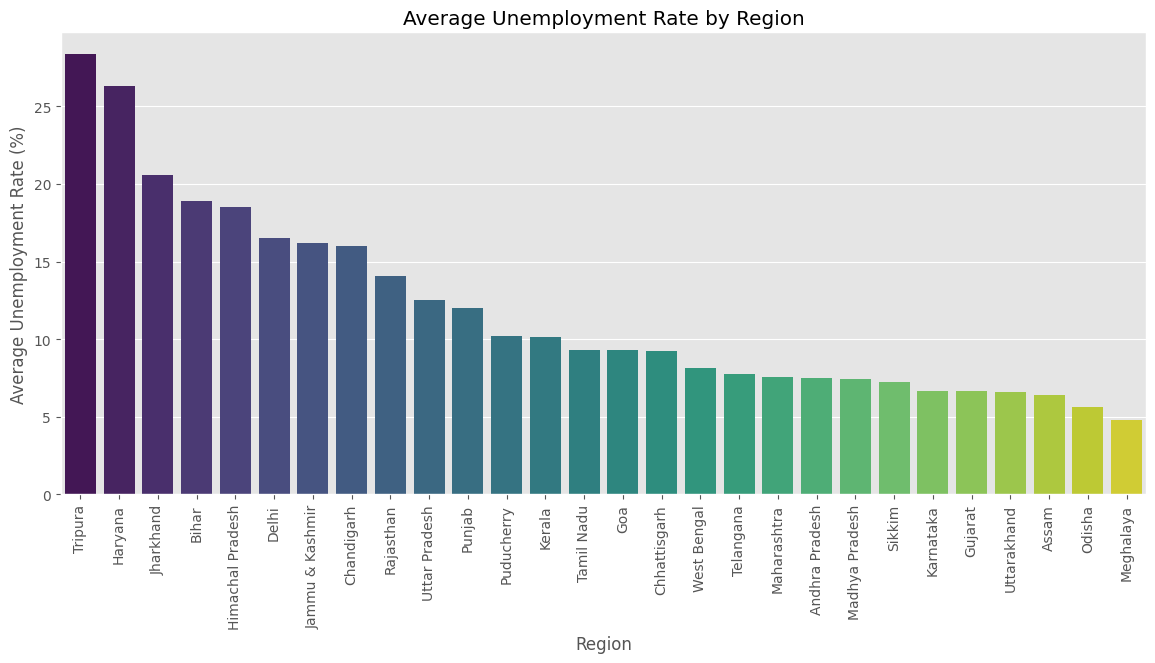

In [51]:
plt.figure(figsize=(14,6))

sns.barplot(
    x=region_avg.index,
    y=region_avg.values,
    palette="viridis",
)

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=90)

plt.show()

### Observation

- Tripura has the highest average unemployment rate among all states.
- Meghalaya has the lowest average unemployment rate.
- Most states have relatively similar unemployment rates, although a few states experience noticeably higher levels.
- These differences suggest that unemployment is not evenly distributed across India and may require region-specific policies and employment initiatives.

## 5.2 Date Conversion

Convert the **Date** column from text format to datetime format to enable time-series analysis.

In [53]:
df["Date"] = pd.to_datetime(df["Date"],dayfirst=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 6 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Estimated Unemployment Rate (%)          740 non-null    float64       
 3   Estimated Employed                       740 non-null    float64       
 4   Estimated Labour Participation Rate (%)  740 non-null    float64       
 5   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 56.6+ KB


## 5.3 Monthly Unemployment Trend

Extract the month from the date column to analyze how unemployment changed over time.

In [54]:
df["Month"] = df["Date"].dt.month_name()
df[["Date", "Month"]].head()

,Date,Month
0,2019-05-31,May
1,2019-06-30,June
2,2019-07-31,July
3,2019-08-31,August
4,2019-09-30,September


### Monthly Average Unemployment Rate

Calculate the average unemployment rate for each month to identify overall monthly trends.

In [55]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_avg = (
    df.groupby("Month")["Estimated Unemployment Rate (%)"]
      .mean()
      .reindex(month_order)
)

monthly_avg

,Estimated Unemployment Rate (%)
Month,
January,9.950755
February,9.964717
March,10.700577
April,23.641569
May,16.646190
June,10.553462
July,9.033889
August,9.637925
September,9.051731


### Visualization

The following line chart shows the average unemployment rate across all states for each month.

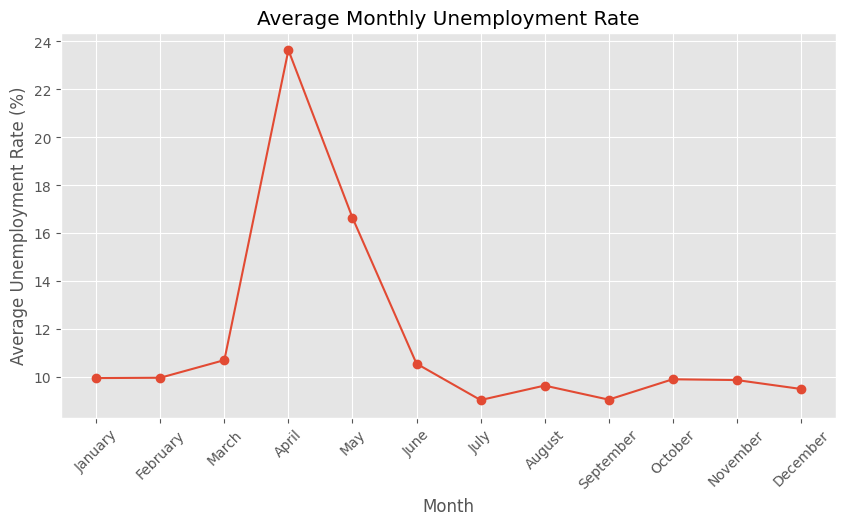

In [56]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker="o"
)

plt.title("Average Monthly Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

### Observation

- The average unemployment rate remained relatively stable during most months.
- A significant spike occurred in **April**, where the unemployment rate reached its highest average value.
- After April, unemployment gradually decreased in the following months.
- This sharp increase is likely associated with the COVID-19 lockdown, which negatively affected employment opportunities across India.

## 5.4 Time-Series Analysis of Selected States

Compare unemployment trends over time for three major Indian states to understand how different regions were affected by the COVID-19 pandemic.

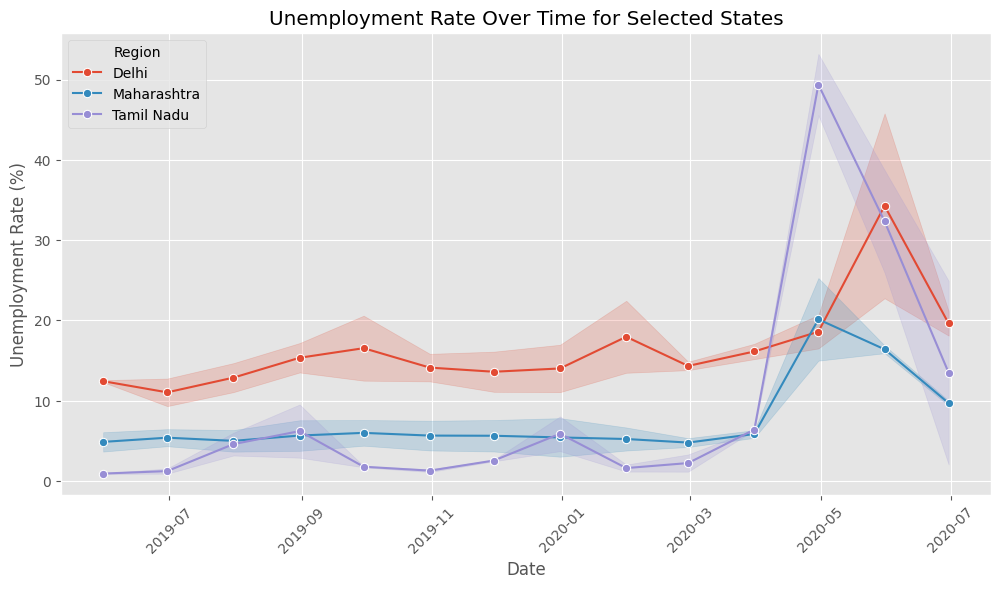

In [57]:
selected_states = [
    "Delhi",
    "Maharashtra",
    "Tamil Nadu"
]

selected_df = df[df["Region"].isin(selected_states)]

plt.figure(figsize=(12,6))

sns.lineplot(
    data=selected_df,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    hue="Region",
    marker="o"
)

plt.title("Unemployment Rate Over Time for Selected States")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

### Observation

- Before the COVID-19 pandemic, Delhi consistently had higher unemployment rates than Maharashtra and Tamil Nadu.
- During the pandemic, all three states experienced a sharp increase in unemployment, with Tamil Nadu showing the largest spike.
- Maharashtra recovered more quickly after the peak, while Delhi remained at relatively higher unemployment levels.
- The analysis suggests that the impact of COVID-19 varied across states, highlighting regional differences in economic resilience.

## 5.5 Top 10 States with Highest Average Unemployment Rate

Identify the ten states with the highest average unemployment rate throughout the observed period.

In [58]:
top10 = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

top10

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


### Visualization

The following chart highlights the top 10 states with the highest average unemployment rates.

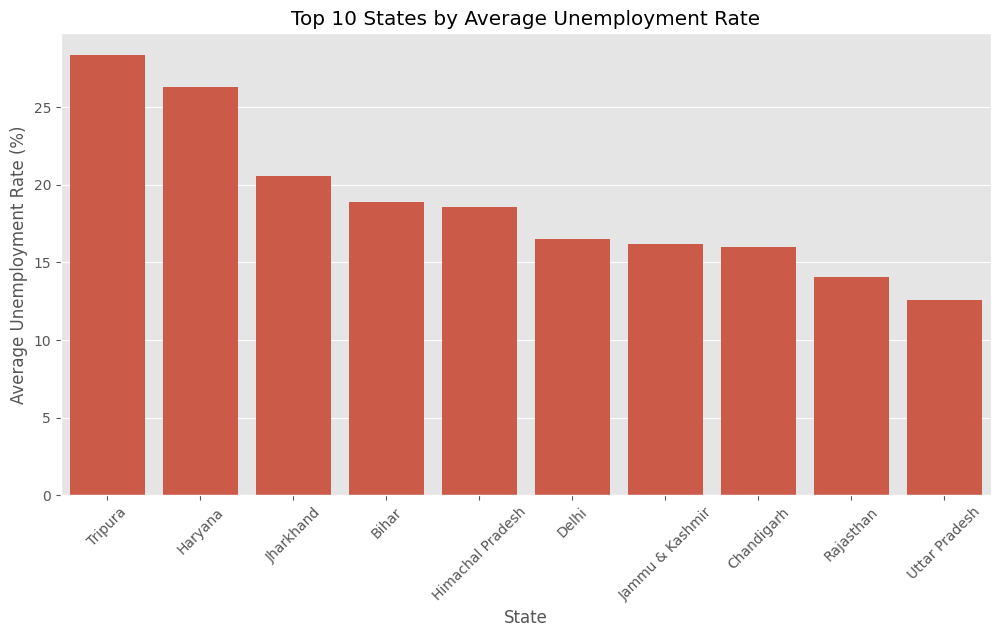

In [59]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top10.index,
    y=top10.values
)

plt.title("Top 10 States by Average Unemployment Rate")
plt.xlabel("State")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.show()

## 5.6 Correlation Analysis

Correlation analysis is used to examine the relationships between numerical variables and identify whether changes in one variable are associated with changes in another.

### Correlation Matrix

The correlation matrix measures the strength and direction of the relationships between numerical variables.

In [60]:
correlation = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
].corr()

correlation

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


### Visualization

The heatmap below illustrates the correlation between the numerical variables in the dataset.

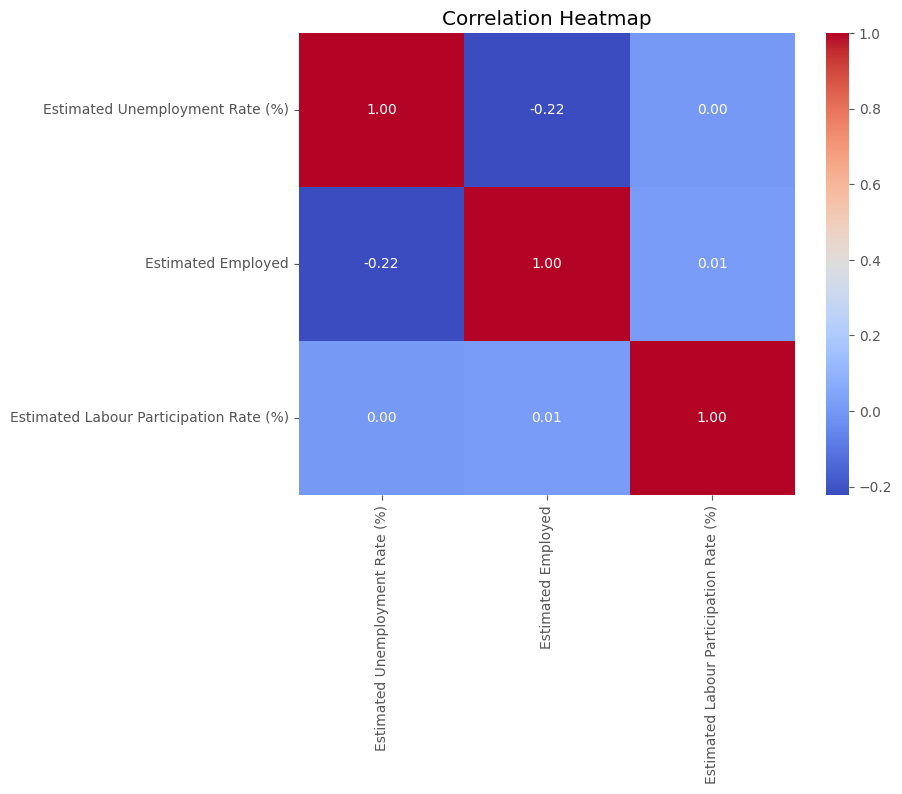

In [61]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- The unemployment rate has a weak negative correlation (-0.22) with the estimated number of employed people.
- The labour participation rate shows almost no linear correlation with the unemployment rate.
- Similarly, the relationship between employment and labour participation is very weak.
- Overall, no strong linear relationships exist among the selected numerical variables in this dataset.

## 5.7 Pre-COVID vs. Post-COVID Analysis

Compare the average unemployment rate before and after the COVID-19 outbreak to measure its overall impact.

In [ ]:
# We will consider the beginning of the impact of Corona on the data 2020-03-01

In [63]:
pre_covid = df[df["Date"] < "2020-03-01"]

post_covid = df[df["Date"] >= "2020-03-01"]

In [64]:
pre_avg = pre_covid["Estimated Unemployment Rate (%)"].mean()

post_avg = post_covid["Estimated Unemployment Rate (%)"].mean()

print("Pre-COVID Average:", round(pre_avg, 2))
print("Post-COVID Average:", round(post_avg, 2))

Pre-COVID Average: 9.51
Post-COVID Average: 17.77


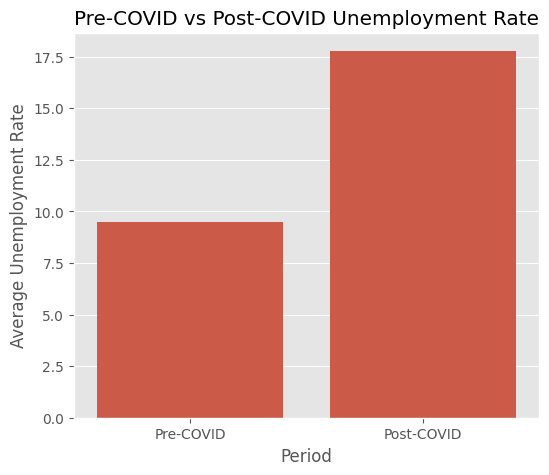

In [65]:
comparison = pd.DataFrame({
    "Period": ["Pre-COVID", "Post-COVID"],
    "Average Unemployment Rate": [pre_avg, post_avg]
})

plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison,
    x="Period",
    y="Average Unemployment Rate"
)

plt.title("Pre-COVID vs Post-COVID Unemployment Rate")

plt.show()

### Observation

- The average unemployment rate increased from **9.51%** before COVID-19 to **17.77%** after the outbreak.
- This represents a substantial increase in unemployment following the pandemic.
- The results indicate that COVID-19 had a significant negative impact on employment opportunities across India.

# 6. Conclusion

This project analyzed unemployment trends in India using Python and data visualization techniques.

Key findings include:

- Tripura recorded the highest average unemployment rate, while Meghalaya had the lowest.
- A significant spike in unemployment occurred during April 2020, coinciding with the COVID-19 lockdown.
- Different states experienced the pandemic differently, with Tamil Nadu showing the largest increase and Maharashtra recovering more quickly.
- Correlation analysis showed no strong linear relationships between unemployment, employment, and labour participation rates.
- The average unemployment rate increased substantially after COVID-19, highlighting the pandemic's economic impact.